In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_US = df[df['job_country'] =='United States']

In [5]:
df_skill = df_US.explode('job_skills')

df_skill[['job_title_short', 'job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,NaN
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,NaN
785705,Data Analyst,sql
785705,Data Analyst,python


In [15]:
df_skill_count = df_skill.groupby(['job_skills', 'job_title_short']).size()
df_skill_count = df_skill_count.reset_index(name='skill count')

df_skill_count.sort_values(by='skill count', ascending = False, inplace=True)

df_skill_count

,job_skills,job_title_short,skill count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [19]:
job_title = df_skill_count['job_title_short'].unique().tolist()

job_title = sorted(job_title[:3])

job_title

['Data Analyst', 'Data Engineer', 'Data Scientist']

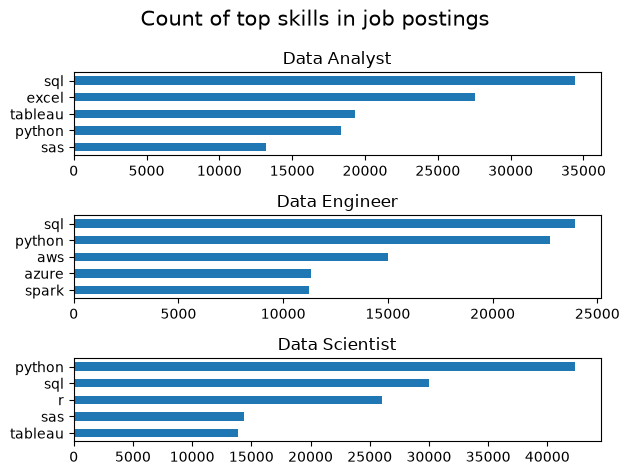

In [56]:
fig, ax = plt.subplots(len(job_title), 1)

for i, title in enumerate(job_title):
    df_plot_4 = df_skill_count[df_skill_count['job_title_short'] == title].head(5)
    df_plot_4.plot(kind ='barh', x='job_skills', y='skill count', ax=ax[i], title=title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Count of top skills in job postings', fontsize=15)
fig.tight_layout()
plt.show()


In [46]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')
df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [50]:
df_skill_percent = pd.merge(df_skill_count,df_job_title_count, how='left', on='job_title_short' )
df_skill_percent['skill_percent'] = 100 * df_skill_percent['skill count'] / df_skill_percent['jobs_total']

df_skill_percent

,job_skills,job_title_short,skill count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


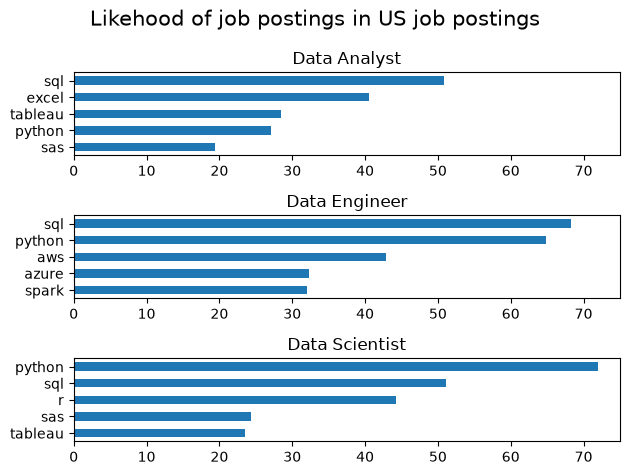

In [55]:
fig, ax = plt.subplots(len(job_title), 1)

for i, title in enumerate(job_title):
    df_plot_4 = df_skill_percent[df_skill_percent['job_title_short'] == title].head(5)
    df_plot_4.plot(kind ='barh', x='job_skills', y='skill_percent', ax=ax[i], title=title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 75)

fig.suptitle('Likehood of job postings in US job postings', fontsize=15)
fig.tight_layout()
plt.show()

C:\Users\weich\AppData\Local\Temp\ipykernel_50032\2766791279.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)
C:\Users\weich\AppData\Local\Temp\ipykernel_50032\2766791279.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)
C:\Users\weich\AppData\Local\Temp\ipykernel_50032\2766791279.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)


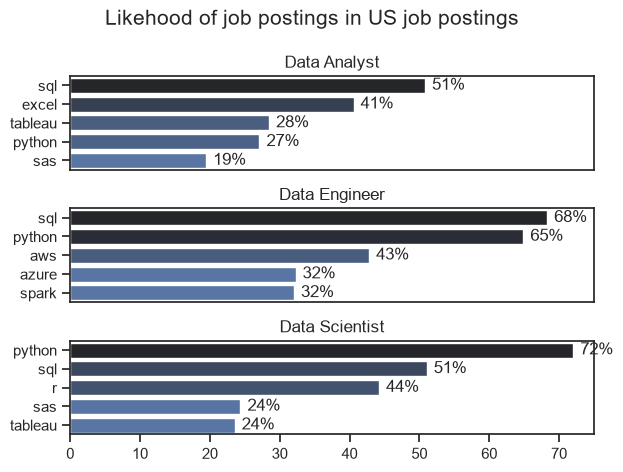

In [75]:
import seaborn as sns

fig, ax = plt.subplots(len(job_title), 1)

for i, title in enumerate(job_title):
    df_plot_4 = df_skill_percent[df_skill_percent['job_title_short'] == title].head(5)

    sns.set_theme(style='ticks')
    sns.barplot(data=df_plot_4, x='skill_percent', y='job_skills',ax=ax[i], hue='skill count', palette='dark:b_r',legend=False)
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 75)

    for n, v in enumerate(df_plot_4['skill_percent']):
        ax[i].text(v+1, n, f'{v:.0f}%', va='center')      #v+1 not close to the bar, va is position slight up or down or center align with their respective bar

    if i!=len(job_title)-1:    #can also write 2 hahaha
        ax[i].set_xticks([])

fig.suptitle('Likehood of job postings in US job postings', fontsize=15)
fig.tight_layout()
plt.show()